In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. load_style merges the shared `base` with this notebook's overrides,
# registers the result for savefig()/extended_palette() and pushes it into rcParams.
from utils.shared_style import apply_style, extended_palette, load_style, savefig, use_style
STYLE = load_style("03_academic_impact")

# --- the analysis data layer -----------------------------------------------------
# Loading, guards, the activity index, the citation windows and the impact table are
# identical for both classification systems, so they live in one module that this
# notebook and its sibling share. Charts stay here; see the module docstring.
from utils import data_analysis_03_academic_impact_analysis as AI

print("palette:", STYLE["colors"])
print("figures ->", STYLE["savedir"], f"(save={STYLE['save']})")


palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']
figures -> output/figures/data_analysis/03_academic_impact (save=False)


In [2]:
# =============================================================================
# ANALYSIS PARAMETERS  --  edit these
# =============================================================================
# This notebook runs the academic-impact analysis over ANZSRC 2020 FIELDS OF RESEARCH.
# Its sibling, 03_academic_impact_02_rcdc_analysis.ipynb, runs the same analysis over
# the NIH disease/condition vocabulary; everything the two must agree on lives in
# src/utils/data_analysis_03_academic_impact_analysis.py, so a guard fixed here
# is fixed there too.
#
# The counts come from
#   src/utils/data_analysis_03_academic_impact_field_counts.py --category for
# run over the Dimensions corpus on the VM, both arms off one file list.
COL_TYPE = "for"

# Which level of the hierarchy to compare on:
#   "L4" = fine field       (e.g. 4202 Epidemiology)
#   "L2" = broad division   (e.g. 42 Health Sciences)
FOR_LEVEL = "L4"

# FOR has no sub-vocabulary to slice; the RCDC notebook uses this to separate diseases
# from cross-cutting tags. Kept here so both notebooks share one build cell verbatim.
RCDC_VIEW = "all"

# The year UK Biobank publications begin in earnest (2013 has only a handful).
UKBB_YEAR = 2014

# How many of UK Biobank's OWN top fields to follow through the whole database.
TOP_N = 8

# Counting metric for the VOLUME charts:
#   "n_papers" = a paper counts once in EVERY field it carries (absolute)
#   "n_frac"   = its weight split evenly across its fields (per-level fractional)
# For FOR the two agree closely (UK Biobank carries 1.51 codes per paper, the database
# 1.42), unlike RCDC where a UK Biobank paper carries nearly twice the tags of an
# average one. Shares of a single field are absolute; anything comparing ACROSS fields
# uses the fractional columns regardless of this line.
WEIGHT = "n_papers"

# CITATION METRICS ------------------------------------------------------------
# The count job attaches three citation quantities to every count:
#   "n_cit"    raw times_cited      — citation mass; accrues with age
#   "n_fcr"    field_citation_ratio — field- AND year-normalised, 1.0 = world average
#   "n_top10"  top-decile indicator — 1.0 if the paper is in the most-cited tenth of
#                                     its (year, type) across the WHOLE corpus
#
# CITE_HEADLINE   the intensity measure the impact map and the time panel lead with.
# CITE_SHARE_METRIC  what Chart 7 tracks: UK Biobank's share of the world's ___ in a
#                 field. Set it to "n_papers" to see the volume baseline on the same
#                 axes, or "n_top10" for the share of the field's best work.
CITE_HEADLINE = "n_fcr"
CITE_SHARE_METRIC = "n_top10"

# A field-window with a handful of UK Biobank papers has a mean citation rate that is
# noise, so the impact measures drop anything thinner than these.
CITE_MIN_DOCS = 50      # over the whole impact window
CITE_MIN_DOCS_YEAR = 20  # within a single year

# How the usable citation window is derived (see the module for the reasoning):
#   a year needs CITE_COV_MIN of papers measured IN BOTH ARMS to be usable at all, and
#   the raw-citation weights then drop CITE_LAG further years, because a 2024 paper has
#   not been cited yet however completely it is indexed.
CITE_COV_MIN = 0.5
CITE_LAG = 1

# WHAT THE ACTIVITY INDEX IS MEASURED AGAINST ---------------------------------
# The index is a ratio of shares, so it depends entirely on what "the database" means:
#   "global"         every paper Dimensions indexes, art history included
#   "universe"       restricted to UNIVERSE_DIVISIONS below
#   "within_parent"  each L4 field against its own L2 division, both arms
#
# Worth knowing before choosing: "universe" divides EVERY field's index by one and the
# same constant (1.86 on this data — UK Biobank has 94% of its mass in those divisions
# against the database's 51%), so it re-ranks nothing; it only moves where parity sits.
# "within_parent" is the one that removes "UK Biobank is a biomedical resource" from
# the comparison per field, and it does re-rank: Public Health reads 3.3x globally and
# 0.9x within Health Sciences — against all research it looks like a speciality, against
# health research UK Biobank is slightly under-represented in it. Epidemiology 51x -> 14x.
ACTIVITY_BASE = "within_parent"
UNIVERSE_DIVISIONS = ("31", "32", "42", "52")   # bio, biomedical, health, psychology

# Analysis window. 2025-26 are dropped on purpose: the Dimensions index is still
# filling in for them, so their counts are not comparable and would fake a collapse.
YEAR_MIN = 2004
YEAR_MAX = 2024

BEFORE_WIN = (YEAR_MIN, UKBB_YEAR - 1)   # marginal-growth window before UK Biobank
AFTER_WIN  = (UKBB_YEAR, YEAR_MAX)       # marginal-growth window after

# LABEL QUALITY GUARD ---------------------------------------------------------
# A year where the background arm's category labels came back blank has no usable
# whole-database denominator, so any share computed from it is meaningless. Both
# guards are tripwires: with both arms counted from one snapshot they are currently
# inert, and that is exactly when they are worth keeping.
BLANK_MAX = 0.05
MASK_BAD_DENOM = True

# VOCABULARY SKEW GUARD -------------------------------------------------------
# A tag whose vocabulary changed between two snapshots has a real numerator and a
# near-empty denominator. Any field where UK Biobank exceeds this share of the world
# is that artefact, not a finding. None keeps them.
SKEW_MAX_SHARE = 5.0

# WHERE THE PARTIALS LIVE ------------------------------------------------------
# One output directory holds every category's partials; they are named per-category.
COUNTS_DIR = P.FOR_COUNTS

print(f"category={COL_TYPE}   level={FOR_LEVEL}   weight={WEIGHT}   top-N={TOP_N}")
print(f"citation: headline={CITE_HEADLINE}  share metric={CITE_SHARE_METRIC}")
print(f"window {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")


category=for   level=L4   weight=n_papers   top-N=8
citation: headline=n_fcr  share metric=n_top10
window 2004-2024   before=(2004, 2013)  after=(2014, 2024)


In [3]:
# =============================================================================
# LOAD THE TWO ARMS, RUN THE GUARDS, DERIVE EVERYTHING
# =============================================================================
# One call does the whole data layer: resolve which partials belong to which arm, drop
# blank-labelled years, build the whole-database denominator (= both arms summed), rank
# UK Biobank's own top categories, compute the activity index, derive the usable
# citation window from coverage, and build the per-category impact table.
#
# It prints what it guarded against as it goes — read that output, it is the difference
# between "this category shrank" and "the classification got sparser that year".
#
# globals().update() is deliberate: it puts the frames into the notebook under their
# own names (whole_ts, TOP_CODES, IMPACT, ...), so a chart cell reads the same here as
# in the RCDC notebook and can be moved between them unchanged. Everything it injects
# is listed in AI.build's docstring.
CTX = AI.build(
    COUNTS_DIR, COL_TYPE,
    level=FOR_LEVEL, rcdc_view=RCDC_VIEW,
    year_min=YEAR_MIN, year_max=YEAR_MAX, ukbb_year=UKBB_YEAR,
    top_n=TOP_N, weight=WEIGHT, palette=extended_palette,
    blank_max=BLANK_MAX, mask_bad_denom=MASK_BAD_DENOM,
    skew_max_share=SKEW_MAX_SHARE,
    cite_headline=CITE_HEADLINE, cite_min_docs=CITE_MIN_DOCS,
    cite_cov_min=CITE_COV_MIN, cite_lag=CITE_LAG,
    activity_base=ACTIVITY_BASE, universe_divisions=UNIVERSE_DIVISIONS,
)
globals().update(CTX)

# Bound to this run's guards, so a chart that has no whole-database series left to draw
# says so on the figure instead of drawing an empty axis.
flag_denominator = AI.denominator_flagger(STYLE, WHOLE_DB_OK, WHOLE_DB_MSG)

_ukbb_overall = (ukbb[ukbb.year.between(*AFTER_WIN)].n_frac.sum()
                 / whole[whole.year.between(*AFTER_WIN)].n_frac.sum() * 100)
print(f"\nUK Biobank is {_ukbb_overall:.3f}% of the whole database over {AFTER_WIN[0]}-"
      f"{AFTER_WIN[1]} (fractional), so read\nthe activity index, not the share, for "
      f"where it concentrates.\n")
print(f"UK Biobank top {TOP_N} {SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}, by {VALUE}, "
      f"{UKBB_YEAR}+):\n")
for code, lab in zip(TOP_CODES, TOP_LABELS):
    tot = int(ukbb[ukbb.for_label == lab][VALUE].sum())
    ai = ACTIVITY.get(code, np.nan)
    print(f"  {AI.short(lab, 44):44s} UKBB {tot:>7,}   share@{YEAR_MAX} "
          f"{pct(share_at(lab), 2):>7s}   activity {ai:5.1f}x")
print(f"\n(activity index measured {ACTIVITY_LABEL} — ACTIVITY_BASE={ACTIVITY_BASE})")


loading for partials from /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_out
  ukbb       5 partial(s), 514 rows, 102 fields, blank labels 0.0%


  background 5 partial(s), 3,591 rows, 171 fields, blank labels 0.0%
  measures: n_papers, n_frac, n_cit, n_cit_frac, n_cit_docs, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_top10, n_top10_frac, n_top10_docs, n_top10_docs_frac
  citation weights: n_cit, n_fcr, n_top10

activity index, 2014-2024 — base=within_parent (within its own L2 division):
  field                                    global  within L2
  Epidemiology                               69.7       14.4
  Genetics                                   19.4        7.5
  Clinical Sciences                           1.6        0.9
  Biological Psychology                       8.3        2.7
  Cardiovascular Medicine and Haematolo…      3.8        2.0
  Public Health                               4.6        0.9
  Oncology and Carcinogenesis                 1.6        0.9
  Nutrition and Dietetics                     7.3        3.9

citation weight coverage (share of papers carrying a value):

  n_cit    ukbb 96

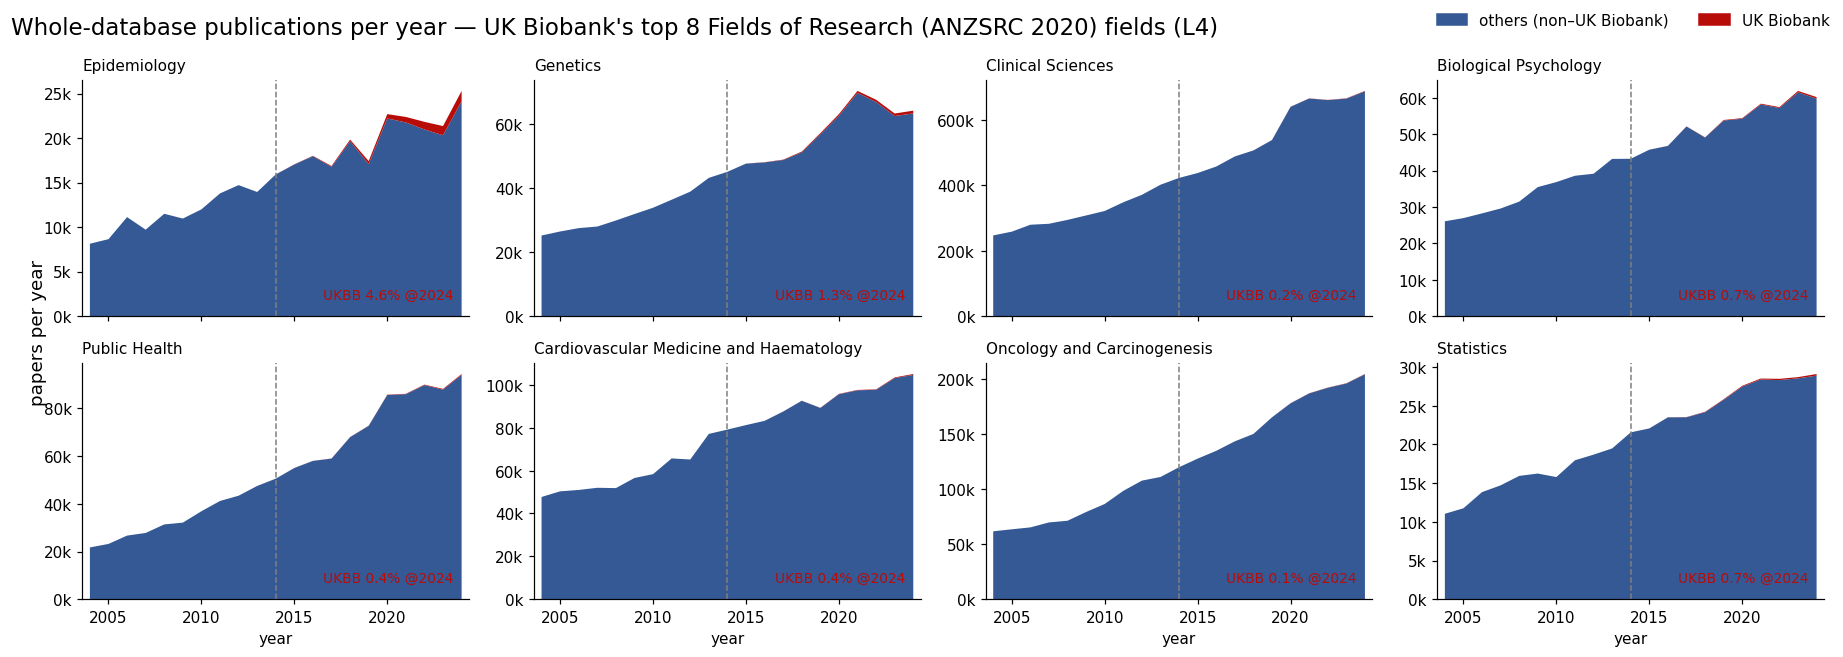

In [4]:
# =============================================================================
# CHART 1 — whole-database growth in UK Biobank's top categories: UKBB vs others
# =============================================================================
# Small multiples, one panel per category. Each panel stacks the category's yearly
# papers into "UK Biobank" vs "everyone else", so you read BOTH the overall trend
# (top of the stack = the whole database) and UK Biobank's slice within it. That
# slice is small in absolute terms, so each panel is annotated with UK Biobank's
# share in the final year. The dashed line marks the first UK Biobank year — a
# time reference, not a claimed cause.
from matplotlib.patches import Patch

C_UKBB = STYLE["colors"][0]     # red  = UK Biobank
C_REST = STYLE["colors"][3]     # blue = everyone else
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")   # 25371 -> "25k"

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    yrs = whole_ts.index.values
    ukb = ukbb_ts[lab].reindex(whole_ts.index).fillna(0.0).values
    rest = whole_ts[lab].values - ukb
    ax.stackplot(yrs, rest, ukb, colors=[C_REST, C_UKBB])
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.annotate(f"UKBB {pct(share_at(lab))} @{YEAR_MAX}",
                xy=(0.96, 0.06), xycoords="axes fraction", ha="right", va="bottom",
                fontsize=STYLE["annot_fs"], color=C_UKBB)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:      # x-label only on the bottom row that exists
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.legend(handles=[Patch(color=C_REST, label="others (non–UK Biobank)"),
                    Patch(color=C_UKBB, label="UK Biobank")],
           loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
fig.suptitle(f"Whole-database publications per year — UK Biobank's top {TOP_N} "
             f"{SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("papers per year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"01_whole_db_trends_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

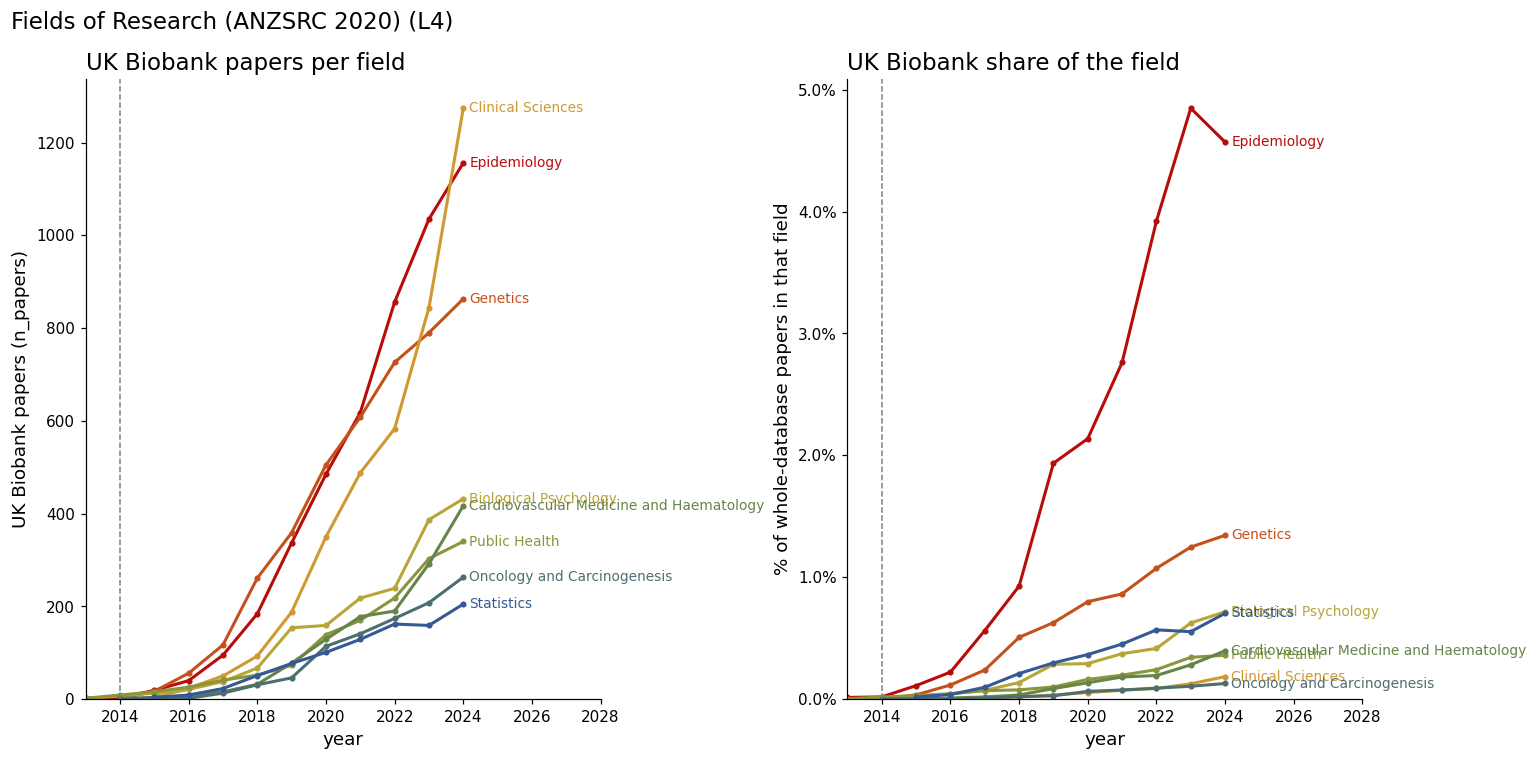

In [5]:
# =============================================================================
# CHART 2 — how much UK Biobank adds, since it started publishing
# =============================================================================
# Left  : UK Biobank's own output in each category (absolute count).
# Right : that output as a SHARE of the whole database in the same category.
# UK Biobank is a small slice of a vast literature, so the share is the truer
# measure of its footprint than the raw count. Categories are direct-labelled on
# both panels; colour follows the category across the whole notebook.
# The left panel comes from the UK Biobank arm alone, so it stays readable even
# when the background arm has no usable labels and the right panel is stamped out.
fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"])

for lab in TOP_LABELS:
    col = FIELD_COLORS[lab]
    axL.plot(ukbb_ts.index, ukbb_ts[lab], color=col, lw=2, marker="o", ms=3)
    axR.plot(share_ts.index, share_ts[lab], color=col, lw=2, marker="o", ms=3)
    yl = ukbb_ts[lab].dropna()
    if len(yl):
        axL.annotate(lab, (yl.index[-1], yl.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")
    yr = share_ts[lab].dropna()
    if len(yr):
        axR.annotate(lab, (yr.index[-1], yr.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")

for ax in (axL, axR):
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_xlabel("year")
    ax.set_ylim(bottom=0)
    ax.set_xlim(UKBB_YEAR - 1, YEAR_MAX + 4)       # room for the direct labels
axL.set_title(f"UK Biobank papers per {UNIT}", loc="left", fontsize=STYLE["title_fs"])
axL.set_ylabel(f"UK Biobank papers ({VALUE})")
axR.set_title(f"UK Biobank share of the {UNIT}{DENOM_NOTE}", loc="left",
              fontsize=STYLE["title_fs"])
axR.set_ylabel(f"% of whole-database papers in that {UNIT}")
# Pick the tick precision from the data: RCDC shares sit below 2%, and a 0-decimal
# formatter would render every tick as "0%" or "1%".
_smax = float(np.nanmax(share_ts.values)) if share_ts.notna().any().any() else 1.0
_nd = 0 if _smax >= 10 else (1 if _smax >= 1 else 2)
axR.yaxis.set_major_formatter(mticker.StrMethodFormatter(f"{{x:.{_nd}f}}%"))
flag_denominator(axR)
fig.suptitle(f"{SYSTEM} ({LEVEL}{VIEW_NOTE})", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"02_ukbb_contribution_{COL_TYPE}_{LEVEL}{FILE_TAG}_{WEIGHT}")
plt.show()

In [6]:
# =============================================================================
# MARGINAL ANNUAL INCREASE SPEED — before vs after UK Biobank
# =============================================================================
# "Marginal speed" = the slope (papers ADDED per year) of a straight-line fit to
# the yearly counts, measured separately in the before- and after-windows. We fit
# it on the WHOLE database (the secular trend) and, for context, on UK Biobank's
# own output.
#
# CAUTION: UK Biobank is far too small (a fraction of a percent of any category) to
# bend the whole-database slope, so the acceleration below is a database-wide trend,
# NOT something UK Biobank caused. The ukbb_after column shows UK Biobank's own pace.
# The whole_* columns come back <NA> when the masking guard left that window empty.
#
# Read `activity_x` before `ukbb_share_%`. The share answers "how much of this topic
# is UK Biobank?" and is bounded by UK Biobank's size, so it is small everywhere by
# construction. The activity index answers "how much MORE of UK Biobank's work is in
# this topic than the literature's?" — 1.0 is parity, 3.0 is triple concentration —
# and that is the question a funder is actually asking.
def slope(frame, code, win, value=VALUE):
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        UNIT: lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_at(lab),
        "activity_x": float(ACTIVITY.get(code, np.nan)),
    })

speed = pd.DataFrame(rows).set_index(UNIT)
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt["activity_x"] = speed_fmt["activity_x"].round(2)
speed_fmt

,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2024_%,activity_x
field,,,,,,
Epidemiology,694,813,1.17,124,4.57,14.36
Genetics,1899,2467,1.30,97,1.34,7.51
Clinical Sciences,16127,30427,1.89,113,0.18,0.87
Biological Psychology,1922,1809,0.94,44,0.72,2.74
Public Health,2875,4726,1.64,34,0.36,0.94
Cardiovascular Medicine and Haematology,2826,2601,0.92,38,0.40,2.05
Oncology and Carcinogenesis,5920,8940,1.51,27,0.13,0.85
Statistics,901,841,0.93,22,0.70,7.58


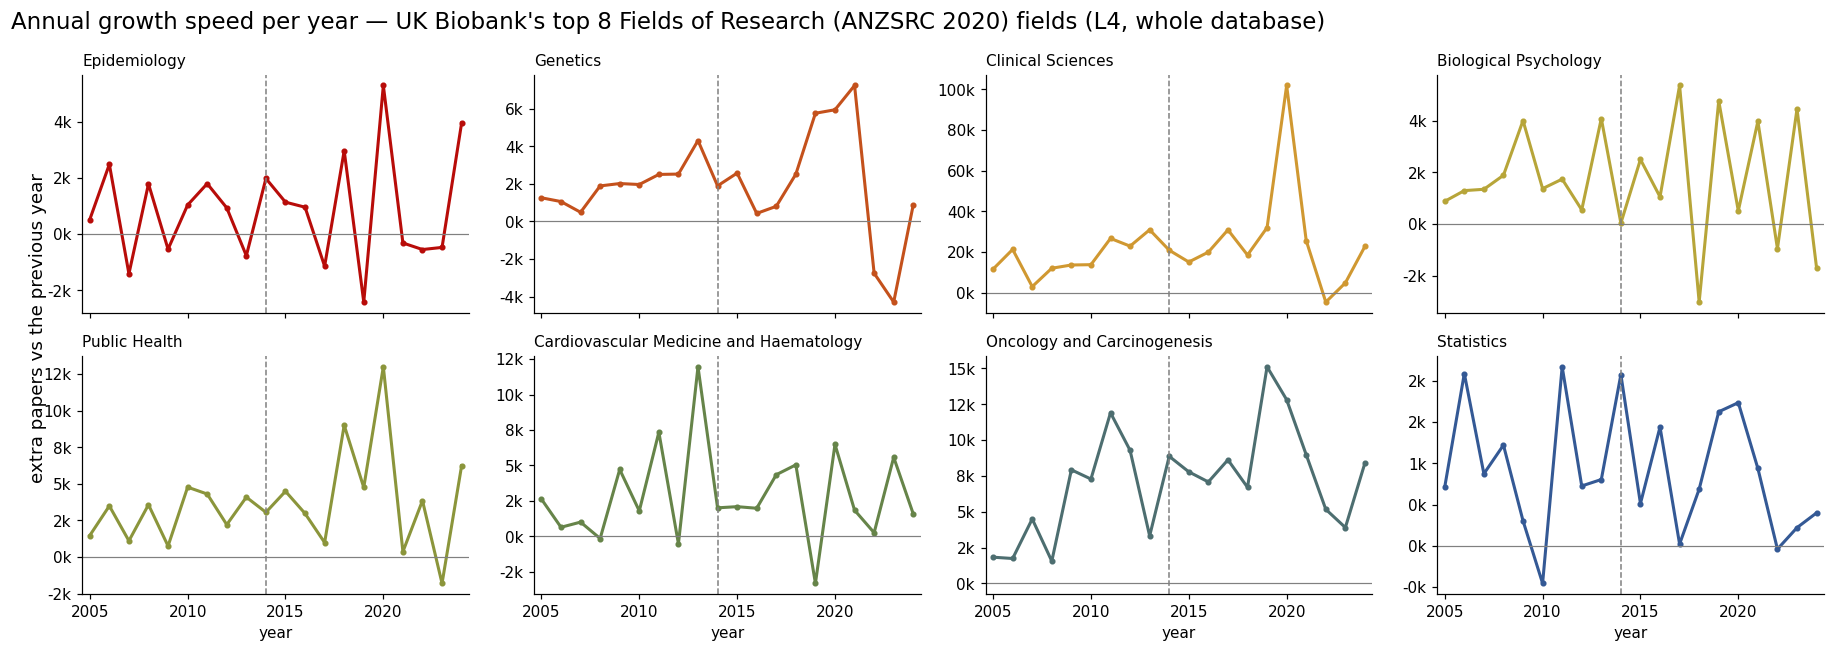

In [7]:
# =============================================================================
# CHART 3 — the growth SPEED of each category, year by year
# =============================================================================
# "Speed" = the annual increase: how many more papers a category gained versus the
# year before (the first difference of Chart 1's whole-database curve). We plot it
# ACROSS years, per category, rather than collapsing it to a single before/after
# number — so the change in pace is shown descriptively, not as a story about a
# cause. The dashed line at UKBB_YEAR is only a time reference; a rise to its
# right is a database-wide trend, and UK Biobank (single-digit % of any category)
# is far too small to have bent these curves.
speed_ts = whole_ts.diff()      # papers gained vs the previous year
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    s = speed_ts[lab].dropna()
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ax.axhline(0, color=STYLE["edgecolor"], lw=0.8)
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.margins(x=0.02)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.suptitle(f"Annual growth speed per year — UK Biobank's top {TOP_N} {SYSTEM} "
             f"{UNIT}s ({LEVEL}{VIEW_NOTE}, whole database){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("extra papers vs the previous year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"03_growth_speed_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

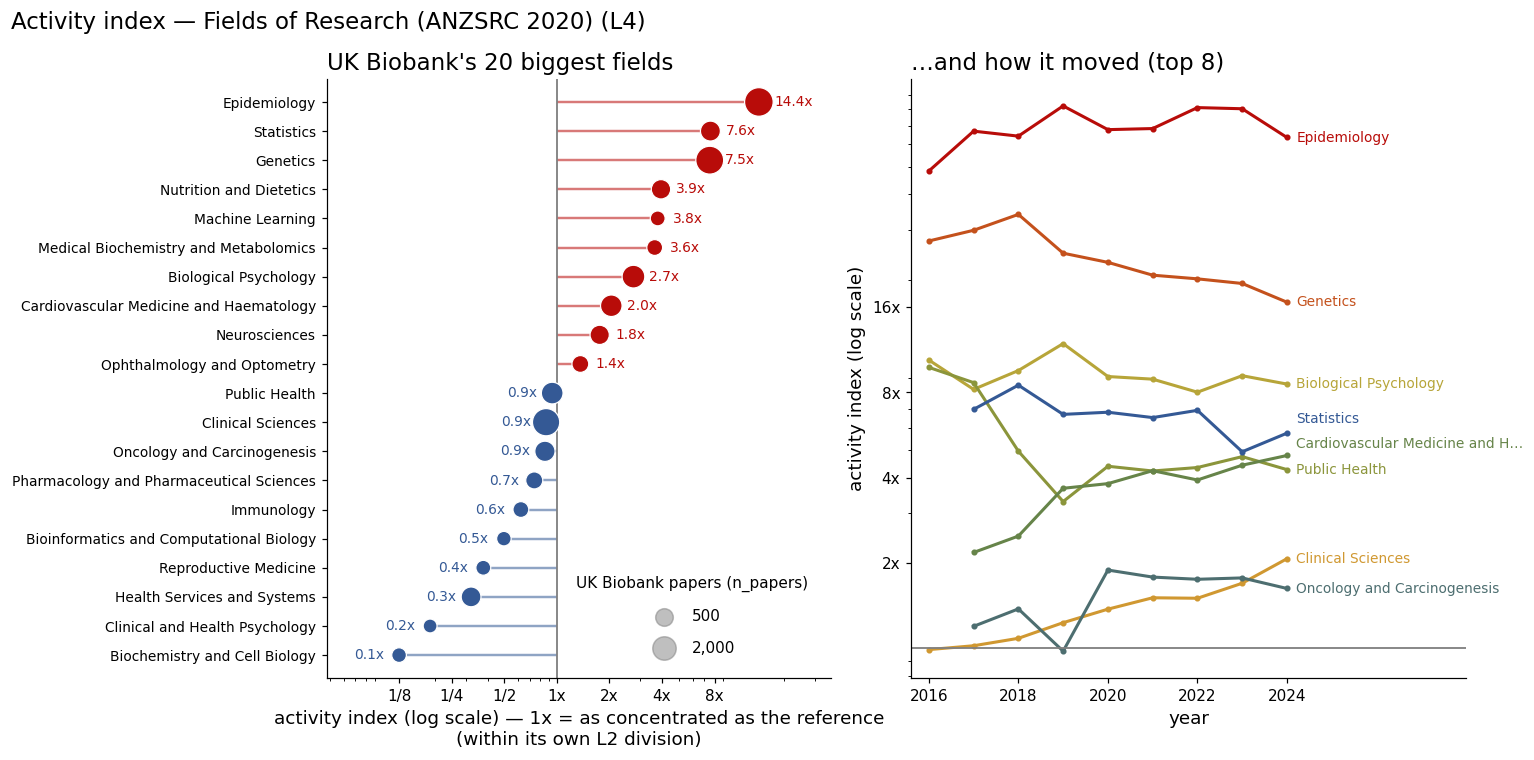

activity index over 2014-2024, UK Biobank's top 20 fields (>1 = over-represented vs the whole database):

  Epidemiology                                          14.36x     4,828 papers
  Statistics                                             7.58x       920 papers
  Genetics                                               7.51x     4,303 papers
  Nutrition and Dietetics                                3.95x       805 papers
  Machine Learning                                       3.78x       197 papers
  Medical Biochemistry and Metabolomics                  3.63x       280 papers
  Biological Psychology                                  2.74x     1,721 papers
  Cardiovascular Medicine and Haematology                2.05x     1,344 papers
  Neurosciences                                          1.76x       784 papers
  Ophthalmology and Optometry                            1.36x       391 papers
  Public Health                                          0.94x     1,387 papers
  Clinical Sci

In [8]:
# =============================================================================
# CHART 4 — the ACTIVITY INDEX: what UK Biobank is disproportionately about
# =============================================================================
# Chart 2's share is bounded by UK Biobank's size (a fraction of a percent of the
# tagged literature), so every category looks tiny there and the ranking mostly
# reproduces "which topics are big". The activity index divides that size out:
#
#     AI = (UK Biobank's papers in X / all UK Biobank papers)
#          -------------------------------------------------
#          (whole database's papers in X / all database papers)
#
# 1.0 = UK Biobank works on X exactly as much as the literature does, 3.0 = three
# times as concentrated, 0.3 = a third. It is a RATIO OF SHARES, so it is computed
# on n_frac whatever WEIGHT says — the same convention as ACTIVITY in the load cell.
#
# Left  : UK Biobank's biggest topics against parity. Log axis, so 2x and 0.5x sit
#         the same distance from the 1.0 line; dot area = UK Biobank papers, so a
#         large dot far to the right is both a big and a distinctive body of work.
# Right : the same index year by year — is the concentration deepening or fading?
#         Category-years carrying fewer than ACT_MIN_N UK Biobank papers are
#         dropped: a ratio of shares built on a handful of papers is noise, which
#         is most of what the first two years after UKBB_YEAR contain.
ACT_TOP_M = 20      # how many of UK Biobank's biggest categories to rank (left)
ACT_MIN_N = 10      # min UK Biobank papers in a category-year to plot it (right)

C_ABOVE, C_BELOW = STYLE["colors"][0], STYLE["colors"][3]   # red over, blue under

# -- left panel data: UK Biobank's ACT_TOP_M biggest categories, ranked by index ----
_rank_m = (ukbb[ukbb.year >= UKBB_YEAR].groupby(["code", "for_label"])[VALUE].sum()
           .sort_values(ascending=False).head(ACT_TOP_M))
act_tbl = (pd.DataFrame({"label": [lab for _, lab in _rank_m.index],
                         "ukbb": _rank_m.to_numpy(),
                         "activity": [ACTIVITY.get(c, np.nan) for c, _ in _rank_m.index]})
           .dropna(subset=["activity"]).sort_values("activity").reset_index(drop=True))

# -- right panel data: the index recomputed within each year ------------------------
# Both arms are re-shared within each year, so a year in which the whole database grew
# does not move the index; only a change in its COMPOSITION does.
_u_year = ukbb.pivot_table(index="year", columns="code", values="n_frac", aggfunc="sum")
_w_year = whole.pivot_table(index="year", columns="code", values="n_frac", aggfunc="sum")
_u_year = _u_year.reindex(index=_w_year.index, columns=_w_year.columns)
act_ts = ((_u_year.div(_u_year.sum(axis=1), axis=0))
          / (_w_year.div(_w_year.sum(axis=1), axis=0)))
act_ts = act_ts.where(_u_year >= ACT_MIN_N).replace([np.inf, -np.inf], np.nan)
act_ts = act_ts.reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.1]})

# ---- left: ranked lollipop against parity ----------------------------------------
ypos = np.arange(len(act_tbl))
colors = [C_ABOVE if a >= 1 else C_BELOW for a in act_tbl.activity]
sizes = 30 + 320 * np.sqrt(act_tbl.ukbb / act_tbl.ukbb.max())
axL.hlines(ypos, 1.0, act_tbl.activity, color=colors, lw=1.6, alpha=0.55)
axL.scatter(act_tbl.activity, ypos, s=sizes, color=colors, zorder=3,
            edgecolor="white", linewidth=0.8)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
for y, a in zip(ypos, act_tbl.activity):
    left = a < 1.0
    axL.annotate(f"{a:.1f}x", (a, y), fontsize=STYLE["annot_fs"],
                 color=C_BELOW if left else C_ABOVE, va="center",
                 ha="right" if left else "left",
                 xytext=(-10 if left else 10, 0), textcoords="offset points")
axL.set_xscale("log")
axL.set_xticks([0.125, 0.25, 0.5, 1, 2, 4, 8])
axL.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:g}x" if x >= 1 else f"1/{1 / x:g}"))
axL.xaxis.set_minor_formatter(mticker.NullFormatter())
axL.set_xlim(act_tbl.activity.min() / 2.6, act_tbl.activity.max() * 2.6)
axL.set_yticks(ypos)
axL.set_yticklabels([short(lab) for lab in act_tbl.label], fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.8, len(act_tbl) - 0.2)
axL.set_xlabel(f"activity index (log scale) — 1x = as concentrated as the reference\n({ACTIVITY_LABEL})")
axL.set_title(f"UK Biobank's {len(act_tbl)} biggest {UNIT}s", loc="left",
              fontsize=STYLE["title_fs"])

# Dot area is a second encoding on this panel, so it needs its own key.
_legend_n = [n for n in (500, 2000, 5000) if n <= act_tbl.ukbb.max()]
axL.legend(handles=[plt.scatter([], [], s=30 + 320 * np.sqrt(n / act_tbl.ukbb.max()),
                                color=STYLE["edgecolor"], alpha=0.5,
                                label=f"{n:,}") for n in _legend_n],
           title=f"UK Biobank papers ({VALUE})", loc="lower right", frameon=False,
           labelspacing=1.1, borderpad=1.0, fontsize=STYLE["legend_fs"],
           title_fontsize=STYLE["legend_fs"])

# ---- right: the index year by year ------------------------------------------------
ends = []                       # (final value, final year, label) for the direct labels
for lab in TOP_LABELS:
    s = act_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)

# Direct labels rather than a legend box, but several series finish within a few
# percent of each other; nudge them apart in log space so none is unreadable.
_lo = min(v for v, _, _ in ends) if ends else 0.5
_hi = max(v for v, _, _ in ends) if ends else 2.0
_gap = 0.045 * (np.log10(_hi / _lo) + 0.4)
_prev = None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Log majors are decades and the whole index lives inside one decade — put the ticks
# on the doublings instead, so the reader can tell 2x from 4x.
_ticks = [t for t in (0.125, 0.25, 0.5, 1, 2, 4, 8, 16) if _lo / 1.6 <= t <= _hi * 1.6]
axR.set_yticks(_ticks)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda y, _: f"{y:g}x" if y >= 1 else f"1/{1 / y:g}"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_years = act_ts.dropna(how="all").index
_y0 = int(_years.min()) if len(_years) else UKBB_YEAR
axR.set_xlim(_y0 - 0.4, YEAR_MAX + 4)        # room for the direct labels
axR.set_xticks(range(_y0, YEAR_MAX + 1, 2))
axR.set_xlabel("year")
axR.set_ylabel("activity index (log scale)")
axR.set_title(f"…and how it moved (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])
flag_denominator(axR)

fig.suptitle(f"Activity index — {SYSTEM} ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"04_activity_index_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

print(f"activity index over {AFTER_WIN[0]}-{AFTER_WIN[1]}, UK Biobank's top "
      f"{len(act_tbl)} {UNIT}s (>1 = over-represented vs the whole database):\n")
for _, r in act_tbl.iloc[::-1].iterrows():
    print(f"  {short(r.label, 52):52s} {r.activity:6.2f}x   {int(r.ukbb):>7,} papers")


In [9]:
# =============================================================================
# CITATION-WEIGHTED METRICS — volume answered "how much", these answer "how well"
# =============================================================================
# IMPACT (built in the cell above) carries, per category, over the impact window:
#
#   rci_<w>     RELATIVE CITATION IMPACT — the mean weight of UK Biobank's papers in X
#               over the mean weight of the whole database's papers in X. 1.0 = cited
#               exactly like everyone else's work in the same category. A MEAN over the
#               papers that carried a value, which is what lets it survive the two arms
#               being measured to different depths (FCR: 97% of the UK Biobank arm,
#               73% of the background).
#   act_<w>     CITATION ACTIVITY INDEX — Chart 4's activity index with citation mass in
#               place of paper counts. Folds volume and impact together.
#   activity_x  the volume activity index recomputed on the impact window, so the
#               columns describe the same years.
#
# The pooled figure comes first: without it a category's 2.5x reads as remarkable when
# the whole corpus sits at 2.4x and the category is merely average FOR UK BIOBANK.
if not CITE_OK:
    print("no usable citation window — the impact section is skipped")
else:
    _u = ukbb[ukbb.year.between(*CITE_WIN)]
    _w = whole[whole.year.between(*CITE_WIN)]
    _mean = lambda f, wt: f[f"{wt}_frac"].sum() / f[f"{wt}_docs_frac"].sum()
    print(f"UK Biobank overall, {CITE_WIN[0]}-{CITE_WIN[1]}, against the whole database"
          f" ({UNIT}-tagged papers):")
    for wt in WEIGHTS_PRESENT:
        label = {"n_cit": "citations per paper", "n_fcr": "field citation ratio",
                 "n_top10": "share in the top decile"}.get(wt, wt)
        fmt = "{:.1%}" if wt == "n_top10" else "{:.2f}"
        print(f"  {label:24s} UKBB {fmt.format(_mean(_u, wt)):>7s}   whole "
              f"{fmt.format(_mean(_w, wt)):>7s}   = {OVERALL[wt[2:]]:.2f}x")

    _head = CITE_HEADLINE[2:]
    cols = (["ukbb_papers", "activity_x"] + [f"rci_{w[2:]}" for w in WEIGHTS_PRESENT]
            + [f"act_{_head}"])
    impact_fmt = (IMPACT.loc[TOP_CODES, cols]
                  .rename(index=dict(zip(TOP_CODES, TOP_LABELS))).round(2))
    impact_fmt["ukbb_papers"] = impact_fmt.ukbb_papers.round(0).astype("Int64")
    impact_fmt.index.name = UNIT
    print(f"\nUK Biobank's top {TOP_N} {UNIT}s — volume beside impact "
          f"({CITE_WIN[0]}-{CITE_WIN[1]}, fractional counts):")
    display(impact_fmt)


UK Biobank overall, 2014-2023, against the whole database (field-tagged papers):
  citations per paper      UKBB   34.19   whole   13.03   = 2.62x
  field citation ratio     UKBB    9.42   whole    3.18   = 2.96x
  share in the top decile  UKBB   38.1%   whole   12.0%   = 3.16x

UK Biobank's top 8 fields — volume beside impact (2014-2023, fractional counts):


,ukbb_papers,activity_x,rci_cit,rci_fcr,rci_top10,act_fcr
field,,,,,,
Epidemiology,3672,14.43,1.48,1.72,2.60,41.58
Genetics,3440,7.63,2.66,3.47,2.73,24.54
Clinical Sciences,2640,0.84,2.02,2.78,3.66,1.37
Biological Psychology,1289,2.77,1.78,2.52,2.47,7.24
Public Health,1047,0.94,2.53,2.95,3.32,4.66
Cardiovascular Medicine and Haematology,927,2.06,3.12,4.38,5.66,5.40
Oncology and Carcinogenesis,734,0.92,1.19,1.71,2.33,0.92
Statistics,715,7.45,2.42,1.88,5.12,3.73


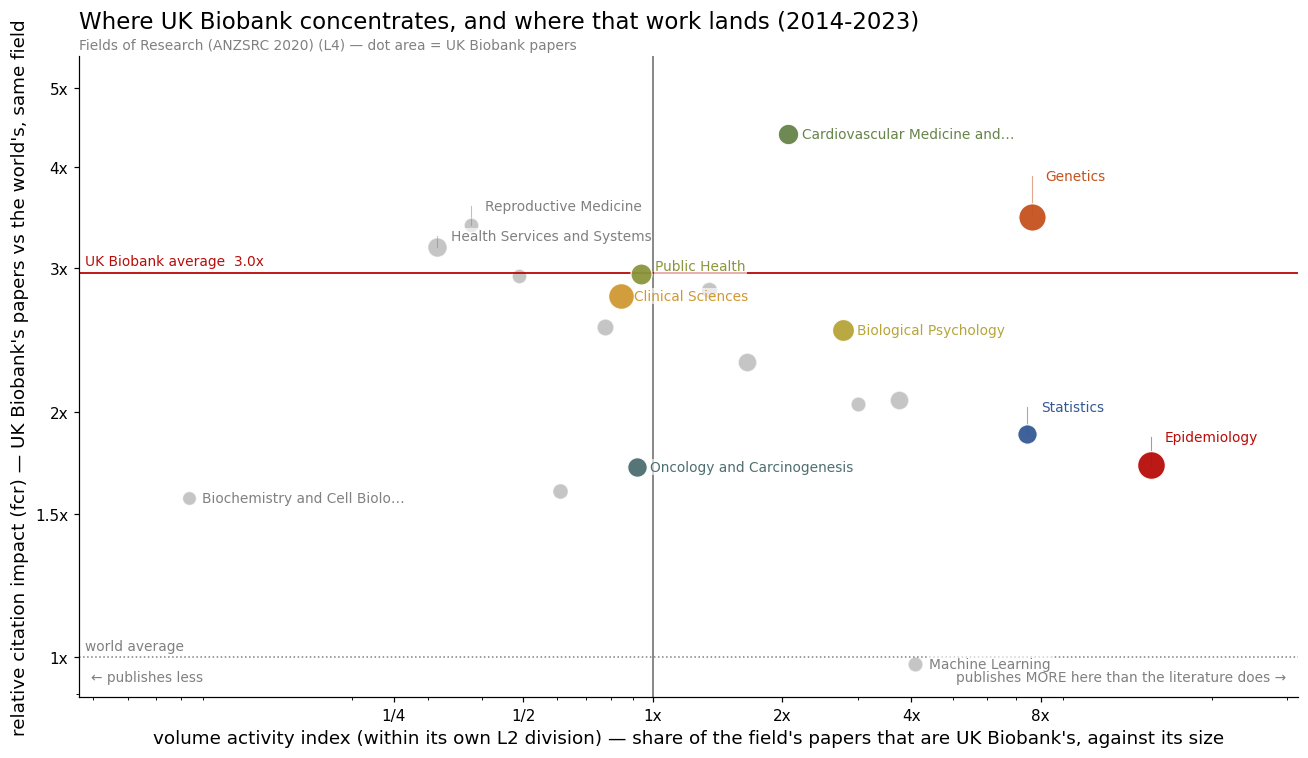

In [10]:
# =============================================================================
# CHART 5 — the map: how MUCH UK Biobank publishes vs how WELL that work lands
# =============================================================================
# The two questions are independent, so they get an axis each. Horizontally, Chart 4's
# volume activity index: is UK Biobank over- or under-represented in this topic?
# Vertically, the relative citation impact: are its papers there cited more than the
# world's papers there? Both are ratios against the whole database and both are drawn
# on log scales, so "twice" and "half" are the same distance from the parity lines.
#
# The horizontal reference is UK Biobank's OWN average impact, not 1.0. Against the
# world, essentially every category is above parity — a resource whose papers are 2.4x
# world average makes that line uninformative. What a portfolio owner needs to know is
# which topics beat UK BIOBANK's own standard, so that is the line drawn solid; world
# parity is the dotted one below it.
CHART5_M = 25          # categories to plot, UK Biobank's biggest first
_head = CITE_HEADLINE[2:]
_rci = f"rci_{_head}"

_big = (IMPACT.dropna(subset=[_rci, "activity_x"])
        .nlargest(CHART5_M, "ukbb_papers"))
_labels = {c: l for c, l in zip(TOP_CODES, TOP_LABELS)}
_ref = OVERALL[_head]

fig, ax = plt.subplots(figsize=STYLE["figsize"])
for code, r in _big.iterrows():
    top = code in _labels
    col = FIELD_COLORS[_labels[code]] if top else STYLE["edgecolor"]
    ax.scatter(r.activity_x, r[_rci], s=30 + 300 * np.sqrt(r.ukbb_papers / _big.ukbb_papers.max()),
               color=col, alpha=0.95 if top else 0.45, zorder=3 if top else 2,
               edgecolor="white", linewidth=0.8)

# Label the top-N (colour-matched to every other chart) plus whatever is extreme on
# either axis — those are the points a reader will ask about. The dementia family sits
# in one tight cluster, so labels are nudged apart in log space as in Chart 4.
_extreme = set(_big.nlargest(3, _rci).index) | set(_big.nsmallest(2, _rci).index) \
    | set(_big.nlargest(3, "activity_x").index) | set(_big.nsmallest(2, "activity_x").index)
_to_label = [(r[_rci], r.activity_x, code) for code, r in _big.iterrows()
             if code in _labels or code in _extreme]
_span = np.log10(_big[_rci].max() / _big[_rci].min())
_gap, _prev = 0.035 * (_span + 0.4), None
for value, xpos, code in sorted(_to_label):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    lab = label_of(code)
    col = FIELD_COLORS[lab] if code in _labels else STYLE["edgecolor"]
    # A nudged label must still point at its own dot, or the reader attaches it to a
    # neighbour; anything moved more than a hair gets a leader line.
    if abs(ly - np.log10(value)) > 0.008:
        ax.plot([xpos, xpos], [value, 10 ** ly], color=col, lw=0.7, alpha=0.5,
                zorder=1)
    ax.annotate(short(lab, 28), (xpos, 10 ** ly), color=col,
                fontsize=STYLE["annot_fs"], va="center",
                xytext=(9, 0), textcoords="offset points",
                bbox=dict(fc="white", ec="none", alpha=0.65, pad=0.6))

# World parity is drawn only when the data comes near it. Every disease UK Biobank
# works in is cited above world average, so forcing 1.0 onto the axis would spend half
# the panel on empty space; when it is off-scale the corner note says so instead.
SHOW_WORLD = _big[_rci].min() < 1.3
ax.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
ax.axhline(_ref, color=STYLE["colors"][0], lw=1.2)
if SHOW_WORLD:
    ax.axhline(1.0, color=STYLE["edgecolor"], lw=1, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
for axis, ticks in ((ax.xaxis, [0.25, 0.5, 1, 2, 4, 8]),
                    (ax.yaxis, [1, 1.5, 2, 3, 4, 5])):
    axis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v:g}x" if v >= 1 else f"1/{1 / v:g}"))
    axis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks([0.25, 0.5, 1, 2, 4, 8])
ax.set_yticks([1, 1.5, 2, 3, 4, 5])
ax.set_xlim(_big.activity_x.min() / 1.8, _big.activity_x.max() * 2.2)
ax.set_ylim((1.0 if SHOW_WORLD else _big[_rci].min()) / 1.12,
            _big[_rci].max() * 1.25)

ax.annotate(f"UK Biobank average  {_ref:.1f}x", (ax.get_xlim()[0], _ref),
            color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
            xytext=(4, 3), textcoords="offset points")
if SHOW_WORLD:
    ax.annotate("world average", (ax.get_xlim()[0], 1.0), color=STYLE["edgecolor"],
                fontsize=STYLE["annot_fs"], va="bottom", xytext=(4, 3),
                textcoords="offset points")
else:
    ax.annotate(f"world average (1x) is below this axis — every {UNIT} shown is "
                f"cited above it", (0.01, 0.08), xycoords="axes fraction", ha="left",
                fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
# Name the halves rather than all four quadrants: with the reference line at UK
# Biobank's own average, "left" and "right" of it is the whole message.
ax.annotate("publishes MORE here than the literature does →", (0.99, 0.02),
            xycoords="axes fraction", ha="right", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
ax.annotate("← publishes less", (0.01, 0.02), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=STYLE["annot_fs"],
            color=STYLE["edgecolor"])

ax.set_xlabel(f"volume activity index ({ACTIVITY_LABEL}) — share of the {UNIT}'s "
              f"papers that are UK Biobank's, against its size")
ax.set_ylabel(f"relative citation impact ({_head}) — UK Biobank's papers vs the "
              f"world's, same {UNIT}")
ax.set_title(f"Where UK Biobank concentrates, and where that work lands "
             f"({CITE_WIN[0]}-{CITE_WIN[1]})", loc="left", fontsize=STYLE["title_fs"],
             pad=18)
# Subtitle as an axes annotation, not a suptitle: a suptitle on a single-panel figure
# collides with the y-label once the ticks are this wide.
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — dot area = UK Biobank papers",
            (0, 1.005), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"05_impact_map_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()


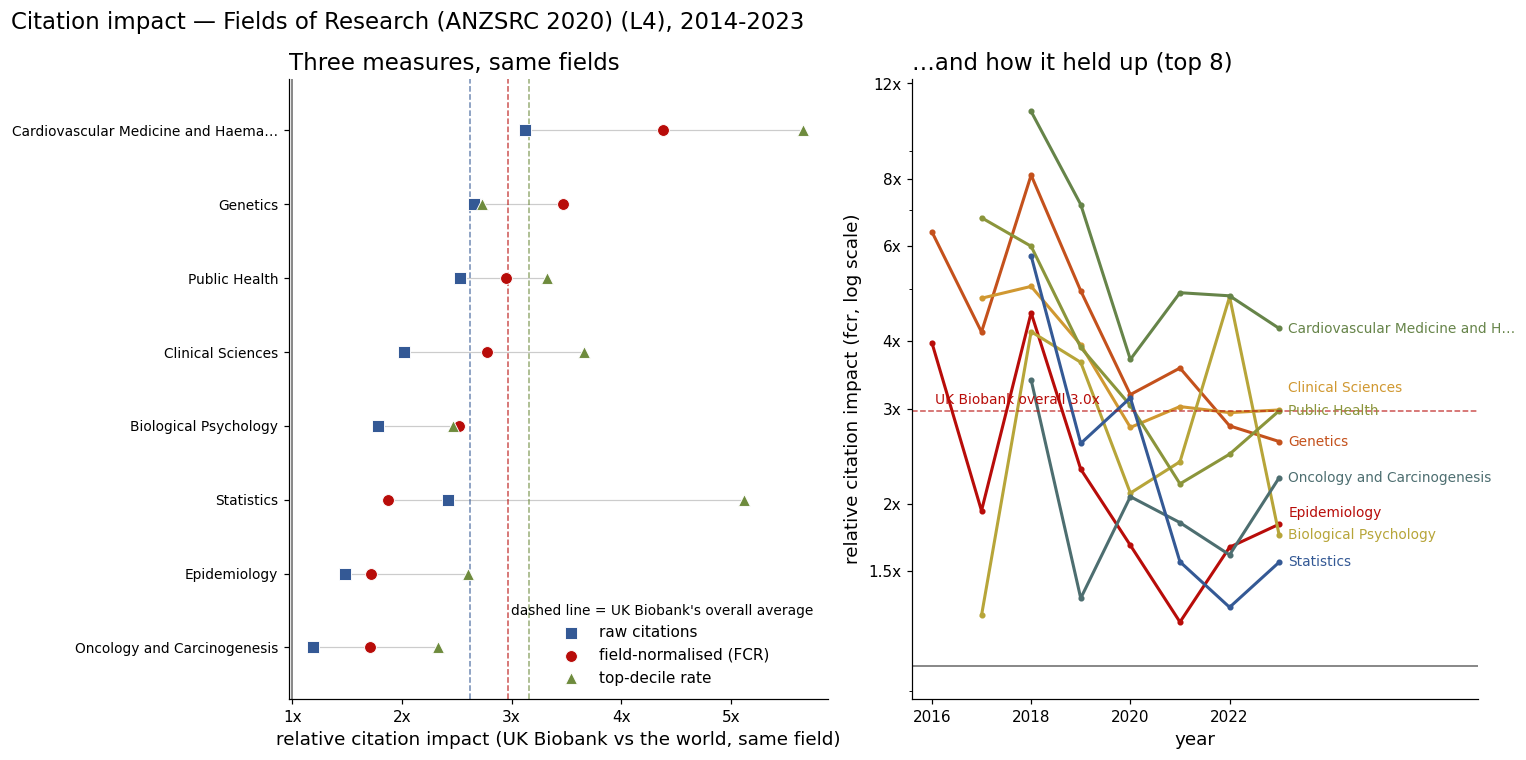

measure agreement over UK Biobank's top 8 fields (spread = max/min across the three weights):
  Cardiovascular Medicine and Haema…   raw  3.1x  field  4.4x  top-d  5.7x   spread 1.81x
  Genetics                             raw  2.7x  field  3.5x  top-d  2.7x   spread 1.31x
  Public Health                        raw  2.5x  field  3.0x  top-d  3.3x   spread 1.31x
  Clinical Sciences                    raw  2.0x  field  2.8x  top-d  3.7x   spread 1.81x
  Biological Psychology                raw  1.8x  field  2.5x  top-d  2.5x   spread 1.42x
  Statistics                           raw  2.4x  field  1.9x  top-d  5.1x   spread 2.73x
  Epidemiology                         raw  1.5x  field  1.7x  top-d  2.6x   spread 1.76x
  Oncology and Carcinogenesis          raw  1.2x  field  1.7x  top-d  2.3x   spread 1.95x


In [11]:
# =============================================================================
# CHART 6 — do the three citation measures agree, and is the impact holding up?
# =============================================================================
# Left: the same categories under all three weights. Citation analysis lives or dies on
# whether a result survives the choice of measure — raw citations reward age and
# citation-heavy fields, FCR divides both out, and the top-decile rate ignores the size
# of the biggest hits entirely. Where the three markers sit together the result is
# robust; where they spread, the ranking is an artefact of the measure and should be
# reported as such. The dashed line of each colour is UK Biobank's OWN average on that
# measure, which is the reference a category should be judged against.
#
# Right: the headline measure year by year. Impact ratios are noisier than volume
# shares — a category-year needs enough UK Biobank papers to have a mean at all — so
# thin cells are dropped rather than drawn as spikes.
CHART6_MIN_DOCS = CITE_MIN_DOCS_YEAR    # set in the parameter block

_head = CITE_HEADLINE[2:]
_order = (IMPACT.loc[[c for c in TOP_CODES if pd.notna(IMPACT.loc[c, f"rci_{_head}"])]]
          .sort_values(f"rci_{_head}"))
W_COLORS = {"n_cit": STYLE["colors"][3], "n_fcr": STYLE["colors"][0],
            "n_top10": STYLE["colors"][2]}
W_MARKERS = {"n_cit": "s", "n_fcr": "o", "n_top10": "^"}
W_NAMES = {"n_cit": "raw citations", "n_fcr": "field-normalised (FCR)",
           "n_top10": "top-decile rate"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.05]})

# ---- left: the three measures side by side ---------------------------------------
ypos = np.arange(len(_order))
for wt in WEIGHTS_PRESENT:
    vals = _order[f"rci_{wt[2:]}"]
    axL.scatter(vals, ypos, s=60, color=W_COLORS[wt], marker=W_MARKERS[wt],
                label=W_NAMES[wt], zorder=3, edgecolor="white", linewidth=0.6)
    axL.axvline(OVERALL[wt[2:]], color=W_COLORS[wt], lw=1, ls="--", alpha=0.7)
# A hairline joining the measures makes the spread readable as one object per row.
for y, (_, r) in zip(ypos, _order.iterrows()):
    vals = [r[f"rci_{w[2:]}"] for w in WEIGHTS_PRESENT]
    axL.plot([min(vals), max(vals)], [y, y], color=STYLE["edgecolor"], lw=0.8,
             alpha=0.4, zorder=1)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
axL.set_yticks(ypos)
axL.set_yticklabels([short(label_of(c), 34) for c in _order.index],
                    fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.7, len(_order) - 0.3)
axL.set_xlabel("relative citation impact (UK Biobank vs the world, same "
               f"{UNIT})")
axL.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
axL.set_title(f"Three measures, same {UNIT}s", loc="left", fontsize=STYLE["title_fs"])
axL.legend(loc="lower right", frameon=False, fontsize=STYLE["legend_fs"],
           title="dashed line = UK Biobank's overall average",
           title_fontsize=STYLE["annot_fs"])

# ---- right: the headline measure, year by year -----------------------------------
rci_ts = (rci_timeseries(CITE_HEADLINE, CHART6_MIN_DOCS)
          .reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1))

ends = []
for lab in TOP_LABELS:
    s = rci_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
# As in Chart 5: world parity earns a line only when the data comes near it.
_dmin, _dmax = np.nanmin(rci_ts.values), np.nanmax(rci_ts.values)
if _dmin < 1.3:
    axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)
axR.axhline(OVERALL[_head], color=STYLE["colors"][0], lw=1, ls="--", alpha=0.7)
axR.annotate(f"UK Biobank overall {OVERALL[_head]:.1f}x",
             (rci_ts.dropna(how="all").index.min(), OVERALL[_head]),
             color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
             xytext=(2, 3), textcoords="offset points")

_lo = min(v for v, _, _ in ends) if ends else 1.0
_hi = max(v for v, _, _ in ends) if ends else 3.0
_gap, _prev = 0.05 * (np.log10(_hi / _lo) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Ticks span the whole series, not just where the lines end — the early years are the
# highest points on this panel and were going unlabelled.
_ticks = [t for t in (0.5, 1, 1.5, 2, 3, 4, 6, 8, 12) if _dmin / 1.2 <= t <= _dmax * 1.2]
axR.set_yticks(_ticks)
axR.set_ylim((1.0 if _dmin < 1.3 else _dmin) / 1.15, _dmax * 1.15)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_yrs = rci_ts.dropna(how="all").index
axR.set_xlim(int(_yrs.min()) - 0.4, int(_yrs.max()) + 4)
axR.set_xticks(range(int(_yrs.min()), int(_yrs.max()) + 1, 2))
axR.set_xlabel("year")
axR.set_ylabel(f"relative citation impact ({_head}, log scale)")
axR.set_title(f"…and how it held up (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])

fig.suptitle(f"Citation impact — {SYSTEM} ({LEVEL}{VIEW_NOTE}), "
             f"{CITE_WIN[0]}-{CITE_WIN[1]}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"06_citation_impact_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()

print(f"measure agreement over UK Biobank's top {TOP_N} {UNIT}s "
      f"(spread = max/min across the three weights):")
for code in _order.index[::-1]:
    vals = [IMPACT.loc[code, f"rci_{w[2:]}"] for w in WEIGHTS_PRESENT]
    lab = label_of(code)
    print(f"  {short(lab, 34):34s} " + "  ".join(
        f"{W_NAMES[w].split()[0][:5]:>5s} {v:4.1f}x" for w, v in zip(WEIGHTS_PRESENT, vals))
        + f"   spread {max(vals) / min(vals):.2f}x")


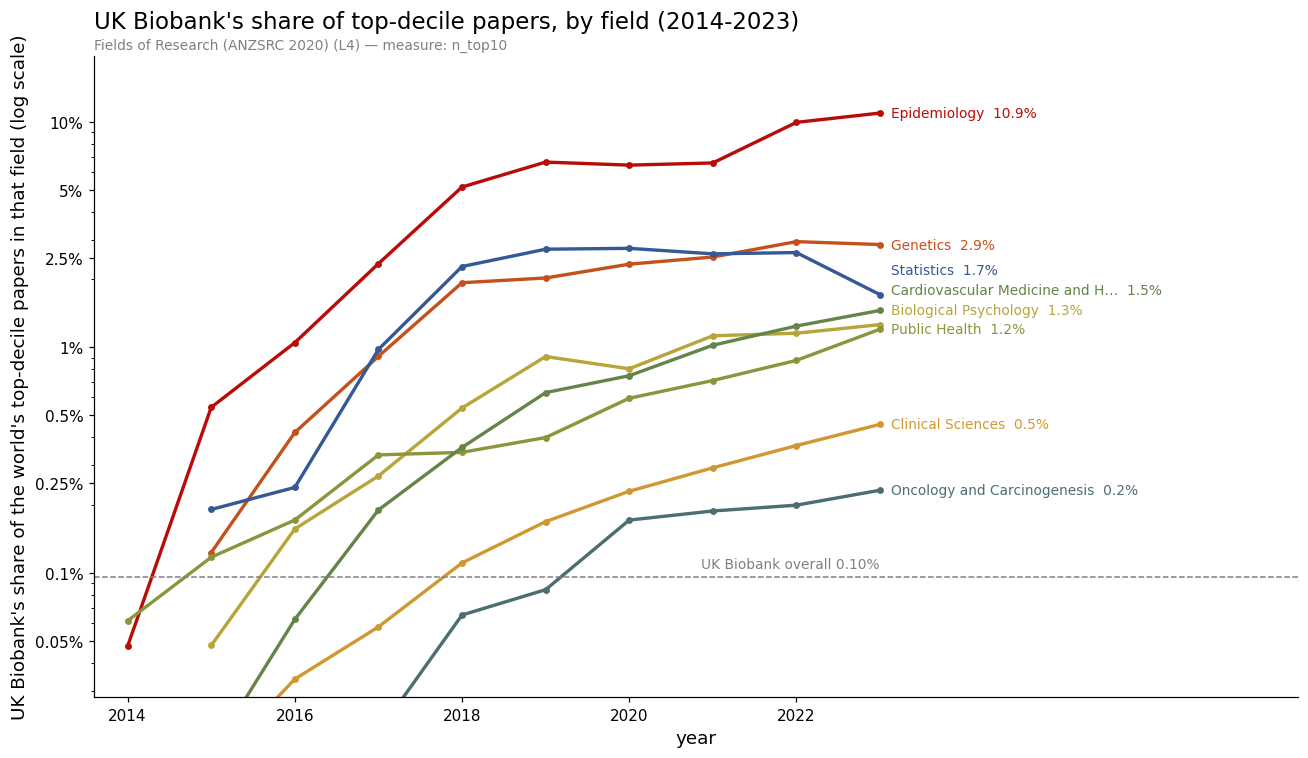

UK Biobank's share of the world's top-decile papers, 2023 (and how it moved since 2014):

  Epidemiology                              10.95%   ( 0.05% in 2014, up 10.90pp)
  Genetics                                   2.86%   ( 0.12% in 2015, up 2.73pp)
  Statistics                                 1.71%   ( 0.19% in 2015, up 1.52pp)
  Cardiovascular Medicine and Haematology    1.46%   ( 0.02% in 2015, up 1.44pp)
  Biological Psychology                      1.26%   ( 0.05% in 2015, up 1.21pp)
  Public Health                              1.20%   ( 0.06% in 2014, up 1.14pp)
  Clinical Sciences                          0.46%   ( 0.01% in 2014, up 0.45pp)
  Oncology and Carcinogenesis                0.23%   ( 0.01% in 2015, up 0.23pp)


In [12]:
# =============================================================================
# CHART 7 — UK Biobank's share of the world's CITATIONS, field by field, over time
# =============================================================================
# Chart 2 asked what share of the world's PAPERS in a field are UK Biobank's. This asks
# what share of the world's CITATIONS in that field are, which is the number a funder
# actually wants: a resource can be 1% of the papers in a field and 3% of its citations,
# and that gap is the whole argument for the resource.
#
# The measure is set once, in the parameter block, by CITE_SHARE_METRIC:
#   n_papers  the volume share — the baseline the citation shares are read against
#   n_cit     share of the field's raw citations
#   n_fcr     share of the field's field-normalised citation weight
#   n_top10   share of the field's TOP-DECILE papers  (see Chart 8)
#
# Shares use the ABSOLUTE columns, not the fractional ones: "UK Biobank's share of
# Epidemiology's citations" is a statement about Epidemiology, so a paper tagged both
# Epidemiology and Genetics belongs whole to each. (The activity index and every impact
# ratio use the fractional columns instead, because those compare ACROSS categories and
# a paper must not be counted twice there.)
_m = CITE_SHARE_METRIC
_mname = {"n_papers": "papers", "n_cit": "citations",
          "n_fcr": "field-normalised citation weight",
          "n_top10": "top-decile papers"}[_m]
_cshare = share_timeseries(_m)
if _m in CITE_YEARS:                      # citation metrics stop where the data does
    _cshare = _cshare.loc[_cshare.index.isin(CITE_YEARS[_m])]
_cshare = _cshare.rename(columns=dict(zip(TOP_CODES, TOP_LABELS)))
# A share of exactly zero has no place on a log axis — matplotlib draws it as a line
# dropping off the bottom of the panel, which reads as a crash rather than as "UK
# Biobank had no papers in this field that year". Blank them instead.
_cshare = _cshare.where(_cshare > 0)

fig, ax = plt.subplots(figsize=STYLE["figsize"])
ends = []
for lab in TOP_LABELS:
    s = _cshare[lab].dropna()
    if not len(s):
        continue
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2.2, marker="o", ms=3.5)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))

# Direct labels carrying the final value, so the chart can be read without the axis.
_lo = min(v for v, _, _ in ends) if ends else 0.1
_hi = max(v for v, _, _ in ends) if ends else 1.0
_gap, _prev = 0.042 * (np.log10(_hi / max(_lo, 1e-6)) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    ax.annotate(f"{short(lab, 30)}  {value:.1f}%", (xend, 10 ** ly),
                color=FIELD_COLORS[lab], fontsize=STYLE["annot_fs"], va="center",
                xytext=(7, 0), textcoords="offset points")

# UK Biobank's overall share of this measure — the line a field has to beat to be one
# of its stronger showings rather than simply a big field.
_u_all = ukbb[ukbb.year.between(*CITE_WIN)][_m].sum()
_w_all = whole[whole.year.between(*CITE_WIN)][_m].sum()
_overall_share = 100 * _u_all / _w_all
ax.axhline(_overall_share, color=STYLE["edgecolor"], lw=1, ls="--")
ax.annotate(f"UK Biobank overall {_overall_share:.2f}%",
            (int(_cshare.dropna(how="all").index.max()), _overall_share),
            color=STYLE["edgecolor"], fontsize=STYLE["annot_fs"], va="bottom",
            ha="right", xytext=(0, 4), textcoords="offset points",
            bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.6))

ax.set_yscale("log")            # shares span two orders of magnitude across fields
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
# The early years are a rounding error against today's shares — a field UK Biobank
# entered in 2015 starts at 0.01% — and letting them set the floor squashes the decade
# that matters into the top inch. The axis starts two decades below the LATEST values
# instead, so the lines enter from the bottom rather than dictating the scale.
_floor = max(_hi / 300, float(np.nanmin(_cshare.values)))
_ticks = [t for t in (0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2.5, 5, 10, 25)
          if _floor / 1.2 <= t <= _hi * 1.6]
ax.set_yticks(_ticks)
ax.set_ylim(_floor / 1.3, _hi * 1.8)
_yrs = _cshare.dropna(how="all").index
ax.set_xlim(int(_yrs.min()) - 0.4, int(_yrs.max()) + 5)
ax.set_xticks(range(int(_yrs.min()), int(_yrs.max()) + 1, 2))
ax.set_xlabel("year")
ax.set_ylabel(f"UK Biobank's share of the world's {_mname} in that {UNIT} (log scale)")
ax.set_title(f"UK Biobank's share of {_mname}, by {UNIT} ({CITE_WIN[0]}-{CITE_WIN[1]})",
             loc="left", fontsize=STYLE["title_fs"], pad=18)
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — measure: {_m}", (0, 1.005),
            xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"07_citation_share_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_m}")
plt.show()

print(f"UK Biobank's share of the world's {_mname}, {CITE_WIN[1]} "
      f"(and how it moved since {CITE_WIN[0]}):\n")
for value, _, lab in sorted(ends, reverse=True):
    s = _cshare[lab].dropna()
    first = float(s.iloc[0])
    arrow = "up" if value > first else "down"
    print(f"  {short(lab, 40):40s} {value:6.2f}%   ({first:5.2f}% in "
          f"{int(s.index[0])}, {arrow} {abs(value - first):.2f}pp)")


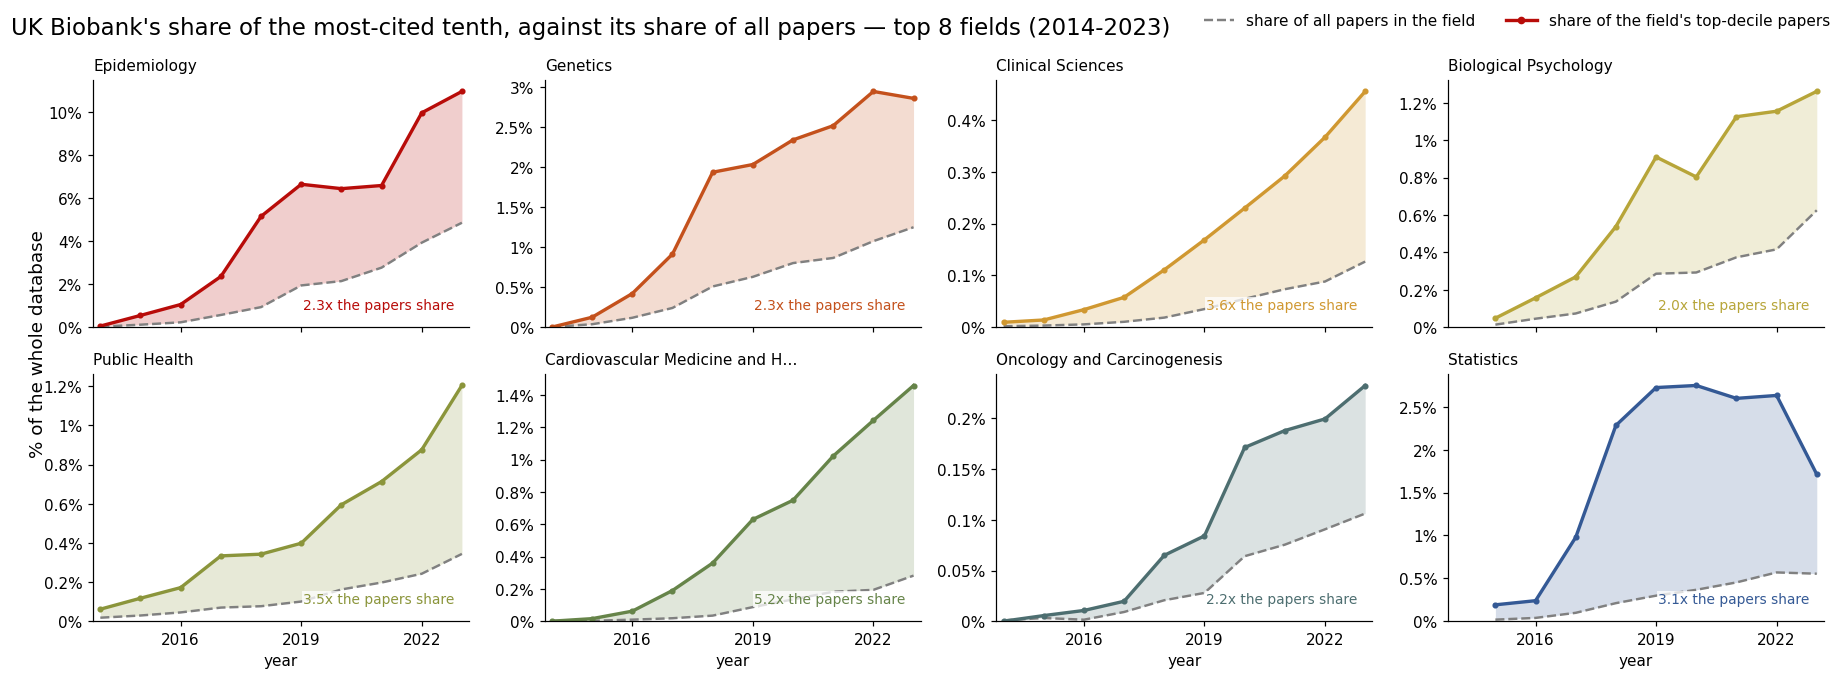

in 2023, UK Biobank held:

  Epidemiology                        10.95% of the top-decile papers vs  4.85% of all papers   = 2.3x
  Genetics                             2.86% of the top-decile papers vs  1.25% of all papers   = 2.3x
  Clinical Sciences                    0.46% of the top-decile papers vs  0.13% of all papers   = 3.6x
  Biological Psychology                1.26% of the top-decile papers vs  0.63% of all papers   = 2.0x
  Public Health                        1.20% of the top-decile papers vs  0.34% of all papers   = 3.5x
  Cardiovascular Medicine and Haema…   1.46% of the top-decile papers vs  0.28% of all papers   = 5.2x
  Oncology and Carcinogenesis          0.23% of the top-decile papers vs  0.11% of all papers   = 2.2x
  Statistics                           1.71% of the top-decile papers vs  0.55% of all papers   = 3.1x


In [13]:
# =============================================================================
# CHART 8 — the top-decile premium: share of the BEST papers vs share of all papers
# =============================================================================
# The most direct statement this data can make. For each field, two lines:
#
#   share of all papers        what fraction of the world's work in this field is
#                              UK Biobank's — its footprint
#   share of top-decile papers what fraction of the field's MOST-CITED tenth is
#                              UK Biobank's — its footprint among the work that landed
#
# If UK Biobank were an average producer in a field the two lines would sit on top of
# each other: holding 2% of the papers would mean holding 2% of the best ones. The
# shaded gap between them is therefore the premium, in the units the reader already
# understands, with no index or ratio in between. The multiplier printed in each panel
# is the two divided — the same quantity Chart 6 calls rci_top10, shown here as the
# thing it is made of.
#
# The top decile is defined per (year, type) over the WHOLE corpus by the count job's
# citdist/thresholds passes, so "top 10%" means top 10% of everything published that
# year, not of UK Biobank's own output.
if "n_top10" not in WEIGHTS_PRESENT:
    print("no n_top10 column — re-run the count job with --weights top10")
else:
    _paper = share_timeseries("n_papers")
    _best = share_timeseries("n_top10")
    _yrs = [y for y in CITE_YEARS["n_top10"]]
    _paper, _best = _paper.loc[_paper.index.isin(_yrs)], _best.loc[_best.index.isin(_yrs)]

    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.1 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        p, b = _paper[code].dropna(), _best[code].dropna()
        idx = p.index.intersection(b.index)
        p, b = p.reindex(idx), b.reindex(idx)
        # Shade the premium, and shade a shortfall in the opposite direction — a field
        # where UK Biobank holds fewer of the best papers than of the papers is a real
        # possibility and must not be drawn as if it were a premium.
        ax.fill_between(idx, p, b, where=(b >= p), color=col, alpha=0.20,
                        interpolate=True, lw=0)
        ax.fill_between(idx, p, b, where=(b < p), color=STYLE["edgecolor"], alpha=0.25,
                        interpolate=True, lw=0)
        ax.plot(idx, p, color=STYLE["edgecolor"], lw=1.6, ls="--")
        ax.plot(idx, b, color=col, lw=2.2, marker="o", ms=3)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        if len(b) and len(p) and p.iloc[-1] > 0:
            ax.annotate(f"{b.iloc[-1] / p.iloc[-1]:.1f}x the papers share",
                        xy=(0.96, 0.06), xycoords="axes fraction", ha="right",
                        va="bottom", fontsize=STYLE["annot_fs"], color=col,
                        bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([], [], color=STYLE["edgecolor"], lw=1.6, ls="--",
               label="share of all papers in the field"),
        Line2D([], [], color=STYLE["colors"][0], lw=2.2, marker="o", ms=4,
               label="share of the field's top-decile papers")],
        loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
    fig.suptitle(f"UK Biobank's share of the most-cited tenth, against its share of all "
                 f"papers — top {TOP_N} {UNIT}s ({CITE_YEARS['n_top10'][0]}-"
                 f"{CITE_YEARS['n_top10'][-1]})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left")
    fig.supylabel("% of the whole database", fontsize=STYLE["label_fs"])
    flag_denominator(fig)
    fig.tight_layout()
    savefig(fig, f"08_top_decile_premium_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = CITE_YEARS["n_top10"][-1]
    print(f"in {_last}, UK Biobank held:\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        p, b = _paper[code].get(_last, np.nan), _best[code].get(_last, np.nan)
        if not (np.isfinite(p) and np.isfinite(b) and p > 0):
            continue
        print(f"  {short(lab, 34):34s} {b:6.2f}% of the top-decile papers vs "
              f"{p:5.2f}% of all papers   = {b / p:.1f}x")


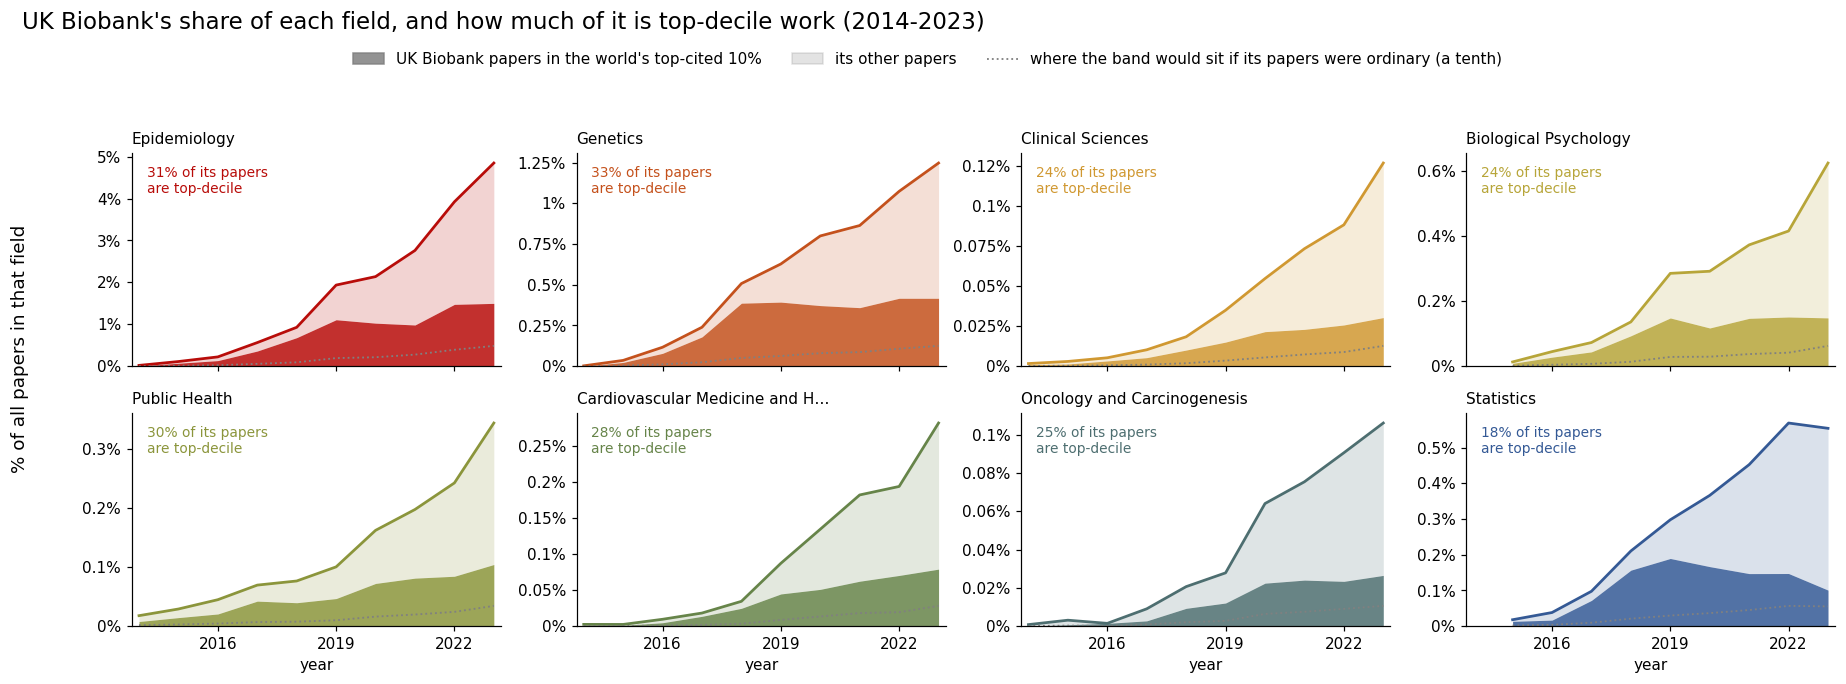

in 2023, of every 100 papers published in each field:

  Epidemiology                      4.85 were UK Biobank's, of which  1.50 were top-decile (30.9% of them, vs ~10% for an ordinary paper)
  Genetics                          1.25 were UK Biobank's, of which  0.42 were top-decile (33.4% of them, vs ~10% for an ordinary paper)
  Clinical Sciences                 0.13 were UK Biobank's, of which  0.03 were top-decile (23.9% of them, vs ~10% for an ordinary paper)
  Biological Psychology             0.63 were UK Biobank's, of which  0.15 were top-decile (23.8% of them, vs ~10% for an ordinary paper)
  Public Health                     0.34 were UK Biobank's, of which  0.10 were top-decile (30.4% of them, vs ~10% for an ordinary paper)
  Cardiovascular Medicine and Hae…  0.28 were UK Biobank's, of which  0.08 were top-decile (28.1% of them, vs ~10% for an ordinary paper)
  Oncology and Carcinogenesis       0.11 were UK Biobank's, of which  0.03 were top-decile (25.0% of them, vs ~10% fo

In [14]:
# =============================================================================
# CHART 9 — the same thing as one quantity: UK Biobank's footprint, split by quality
# =============================================================================
# Chart 8 draws two shares and asks the reader to compare them. This draws ONE share —
# UK Biobank's slice of the field, exactly the dashed line from Chart 8 — and colours
# the part of it that landed in the world's most-cited tenth:
#
#     total height   UK Biobank's papers as a % of all the field's papers
#     coloured band  those of them in the top decile, as a % of all the field's papers
#     pale band      the rest of UK Biobank's papers
#
# So the height is the footprint and the colour is the quality inside it, with no second
# line to hold in your head. The dotted line inside each panel is the same band as it
# would be if UK Biobank's papers were ordinary — a tenth of its own output, since the
# decile is defined over the whole corpus. Colour reaching above that line is the entire
# claim; the ratio of the band to the dotted line is Chart 8's multiplier.
#
# HOW THE TOP DECILE IS DEFINED (the citdist / thresholds passes of the count job)
#   1. citdist walks the whole corpus and builds an EXACT histogram of times_cited per
#      (year, type) — citations are small integers, so no sampling or sketching.
#   2. thresholds turns each histogram into the lowest citation count whose "at least
#      this many" tail is still within the top 10%. Citations are tied and lumpy (a
#      fifth of all papers have none), so an exact 10% is usually unreachable; the cut
#      is taken conservatively and the achieved share is recorded in cit_thresholds.csv
#      — 9.3-10.0% for recent article years.
#   3. A paper scores 1.0 on n_top10 if its times_cited reaches its own (year, type)
#      cut-off. For articles that is >=49 citations in 2014, >=17 in 2022, >=10 in 2023
#      — the bar falls with age, which is the point of setting it per year.
#
# The decile is global, NOT per field: it is the top tenth of everything published that
# year of that type, so a field that is cited heavily overall (oncology) will have more
# than a tenth of its papers in it and a slow-citing field fewer. That is why this chart
# compares UK Biobank against the same field rather than across fields — and why the
# field-normalised FCR, not this, is the headline for cross-field comparisons.
if "n_top10" not in WEIGHTS_PRESENT:
    print("no n_top10 column — re-run the count job with --weights top10")
else:
    _all = share_timeseries("n_papers")                              # the footprint
    _best = share_timeseries("n_top10", denominator="n_papers")      # its top-decile part
    _yrs = CITE_YEARS["n_top10"]
    _all = _all.loc[_all.index.isin(_yrs)]
    _best = _best.loc[_best.index.isin(_yrs)]
    # What the coloured band would be if UK Biobank's papers were ordinary: a tenth of
    # its own footprint, because the decile is a tenth of the corpus by construction.
    _par = _all * 0.10

    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.1 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b = _all[code].dropna(), _best[code].dropna()
        idx = a.index.intersection(b.index)
        a, b = a.reindex(idx), b.reindex(idx)
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, a, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        ax.plot(idx, _par[code].reindex(idx), color=STYLE["edgecolor"], lw=1.2, ls=":")
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        if len(a) and a.iloc[-1] > 0:
            ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}% of its papers\nare "
                        f"top-decile", xy=(0.04, 0.94), xycoords="axes fraction",
                        ha="left", va="top", fontsize=STYLE["annot_fs"], color=col)
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # The legend describes the ENCODING, not any one field, so its patches are neutral
    # grey — in red they would read as "red = top decile" when every panel has its own
    # colour. It sits on its own line under the title rather than beside it, which a
    # three-entry legend cannot share with a full-width heading.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="UK Biobank papers in the world's top-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22, label="its other papers"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.2, ls=":",
               label="where the band would sit if its papers were ordinary (a tenth)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    fig.suptitle(f"UK Biobank's share of each {UNIT}, and how much of it is top-decile "
                 f"work ({_yrs[0]}-{_yrs[-1]})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    # tight_layout does not know about the suptitle, the legend line or the supylabel;
    # the rect leaves room for all three.
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"09_footprint_quality_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = _yrs[-1]
    print(f"in {_last}, of every 100 papers published in each {UNIT}:\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        a, b = _all[code].get(_last, np.nan), _best[code].get(_last, np.nan)
        if not (np.isfinite(a) and np.isfinite(b) and a > 0):
            continue
        print(f"  {short(lab, 32):32s} {a:5.2f} were UK Biobank's, of which {b:5.2f} "
              f"were top-decile ({100 * b / a:4.1f}% of them, vs ~10% for an "
              f"ordinary paper)")
